In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

os.chdir('..')

from src.decorators import EM
from src.models import TailRobustPCACV
from src.models import NipalsPCA
from src.utils.functional import subspace_overlap_score

In [2]:
# Load & date conversion
path = os.path.join("data", "processed", "2026-03-MD.csv")
df = pd.read_csv(path, index_col=0)

df.index = pd.to_datetime({
    'year': df.index.astype(int),
    'month': (np.round((df.index % 1) * 12) + 1).astype(int),
    'day': 1
})

# Drop specific columns and the "ragged" last row
df.drop(columns=["ACOGNO", "UMCSENTx", "TWEXAFEGSMTHx", "ANDENOx"], 
        errors='ignore', inplace=True)
df = df.iloc[:-1]

# Remove outliers
dev = (df - df.median()).abs()
iqr = df.quantile(0.75) - df.quantile(0.25)

df = df.where(dev <= 10 * iqr)

# Standardize
df = pd.DataFrame(
    StandardScaler().fit_transform(df), 
    index=df.index, 
    columns=df.columns
)

print(f"Data shape: {df.shape}")

Data shape: (803, 122)


In [5]:
# --- 1. Imputation
em_imputer = EM(tf=PCA(n_components=8), max_iter=1000)
df_imputed, _ = em_imputer(df)
df_imputed = pd.DataFrame(
    df_imputed, 
    index=df.index, 
    columns=df.columns
)
print(f"Imputed data has shape: {df_imputed.shape}")

# --- 2. Outlier removal (once for all)
tr_pca = TailRobustPCACV(n_components=8).fit(df_imputed)
model = tr_pca.best_estimator_
df_processed = model.inverse_transform(model.transform(df_imputed))
df_processed = pd.DataFrame(df_processed, index=df.index, columns=df.columns)

c:\Users\Lenovo\Desktop\master-thesis\src\decorators\em.py:126: ConvergenceWarning: EM did not converge after 1000 iterations.
  warnings.warn(


Imputed data has shape: (803, 122)


In [6]:
# --- Parameters ---
window = 480
num_factors = 8

# Container for factors (aligned with out-of-sample dates)
factors_idx = df_processed.index[window:]
factors = pd.DataFrame(index=factors_idx, columns=[f"F{i}" for i in range(1, num_factors+1)])

pca = PCA(n_components=num_factors)
prev_loadings = None

# --- Rolling Window Loop ---
for i, t in enumerate(range(window, len(df_processed))):
    
    # 1. Rolling window slice
    X_slice = df_processed.iloc[t-window : t].values
    
    # 2. Estimate loadings (P)
    pca.fit(X_slice)
    current_loadings = pca.components_ # Shape: (num_factors, num_features)
    
    # 3. Individual Factor Sign Alignment (Sign Consistency)
    if prev_loadings is not None:
        for f in range(num_factors):
            # If dot product is negative, the factor flipped polarity
            if np.dot(current_loadings[f], prev_loadings[f]) < 0:
                current_loadings[f] *= -1
    
    # Store current as reference for the next window
    prev_loadings = current_loadings.copy()
    
    # 4. Out-of-sample Factor Extraction
    # Project current observation x_t onto the estimated loadings
    x_t = df_processed.iloc[t].values
    factors.iloc[i] = x_t @ current_loadings.T

print(f"Factors estimated from {factors.index[0]} to {factors.index[-1]}")

Factors estimated from 1999-04-01 00:00:00 to 2026-02-01 00:00:00


In [10]:
groups = {
    "Real Activity": list(range(0, 19)) + [118],
    "Labor Market": list(range(19, 47)),
    "Housing": list(range(47, 57)),
    "Inventories and Orders": list(range(57, 61)),
    "Money and Credit": list(range(61, 71)) + [119, 120], 
    "Stock Market & VIX": list(range(71, 74)) + [121],
    "Treasury Rates": list(range(74, 81)),
    "Corporate Bond Spreads": list(range(81, 95)),
    "Prices and Earnings": list(range(95, 118)),
}

def plot_factor_corr_profile(corr_table, groups, factor_idx=0, is_distance_corr=False):
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(groups)))
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

    curr, ticks = 0, []

    for i, (name, idxs) in enumerate(groups.items()):
        # Pulling correlation values for the specific factor
        vals = corr_table.iloc[idxs, factor_idx].values
        x = np.arange(curr, curr + len(vals))
        
        ax.bar(x, vals, width=0.8, color=colors[i], alpha=0.9, zorder=3)
        
        ticks.append(curr + len(vals) / 2)
        curr += len(vals) + 2 

    # Formatting axes
    ax.set_xticks(ticks)
    ax.set_xticklabels(groups.keys(), fontsize=10, rotation=35, ha='right')
    
    if is_distance_corr:
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Distance Correlation ($dCor$)", fontsize=11, labelpad=10)
    else:
        ax.set_ylim(-1.05, 1.05)
        ax.set_ylabel("Correlation Coefficient ($\\rho$)", fontsize=11, labelpad=10)
    
    ax.axhline(0, color='#333333', linewidth=1.2, zorder=4)
    
    # Significance reference lines
    ref_line_style = dict(color='#dddddd', linestyle='--', linewidth=0.8, zorder=1)
    ax.axhline(0.5, **ref_line_style)
    if not is_distance_corr:
        ax.axhline(-0.5, **ref_line_style)

    # Styling spines
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_color('#cccccc')

    ax.yaxis.grid(True, color='#f5f5f5', linestyle='-', zorder=0)
    
    title_type = "Distance" if is_distance_corr else "Linear"
    plt.title(f"Factor {factor_idx + 1} {title_type} Correlation Profile", 
              loc='left', fontsize=14, fontweight='bold', pad=25)
    
    plt.tight_layout()
    plt.show()

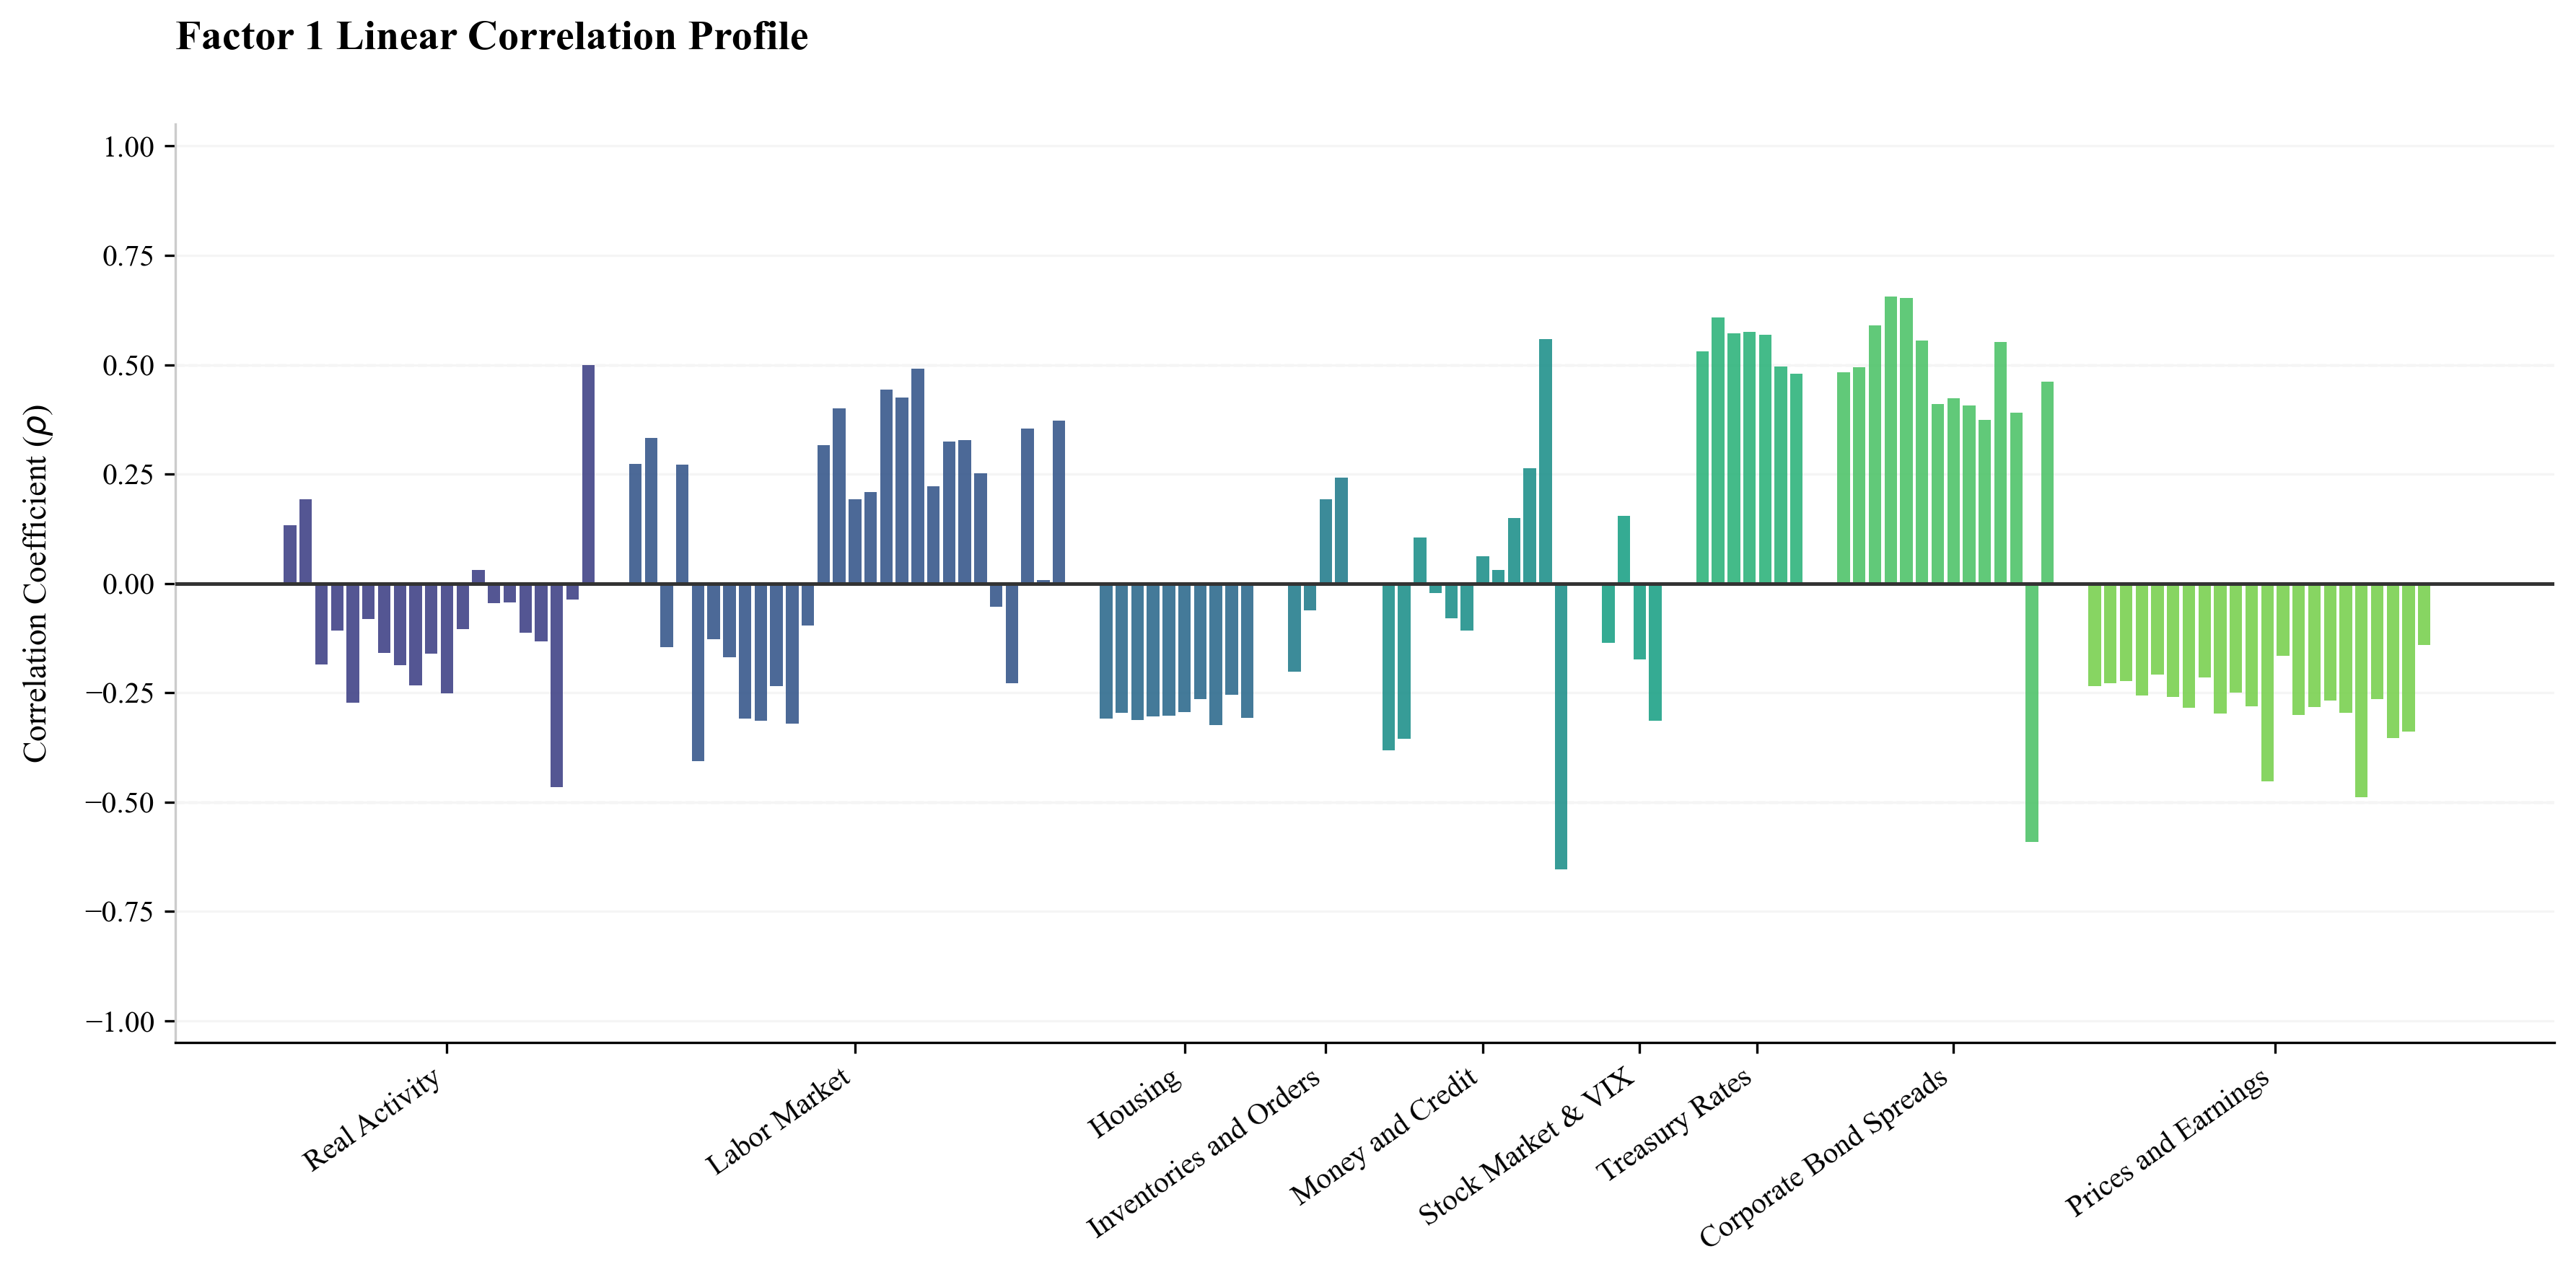

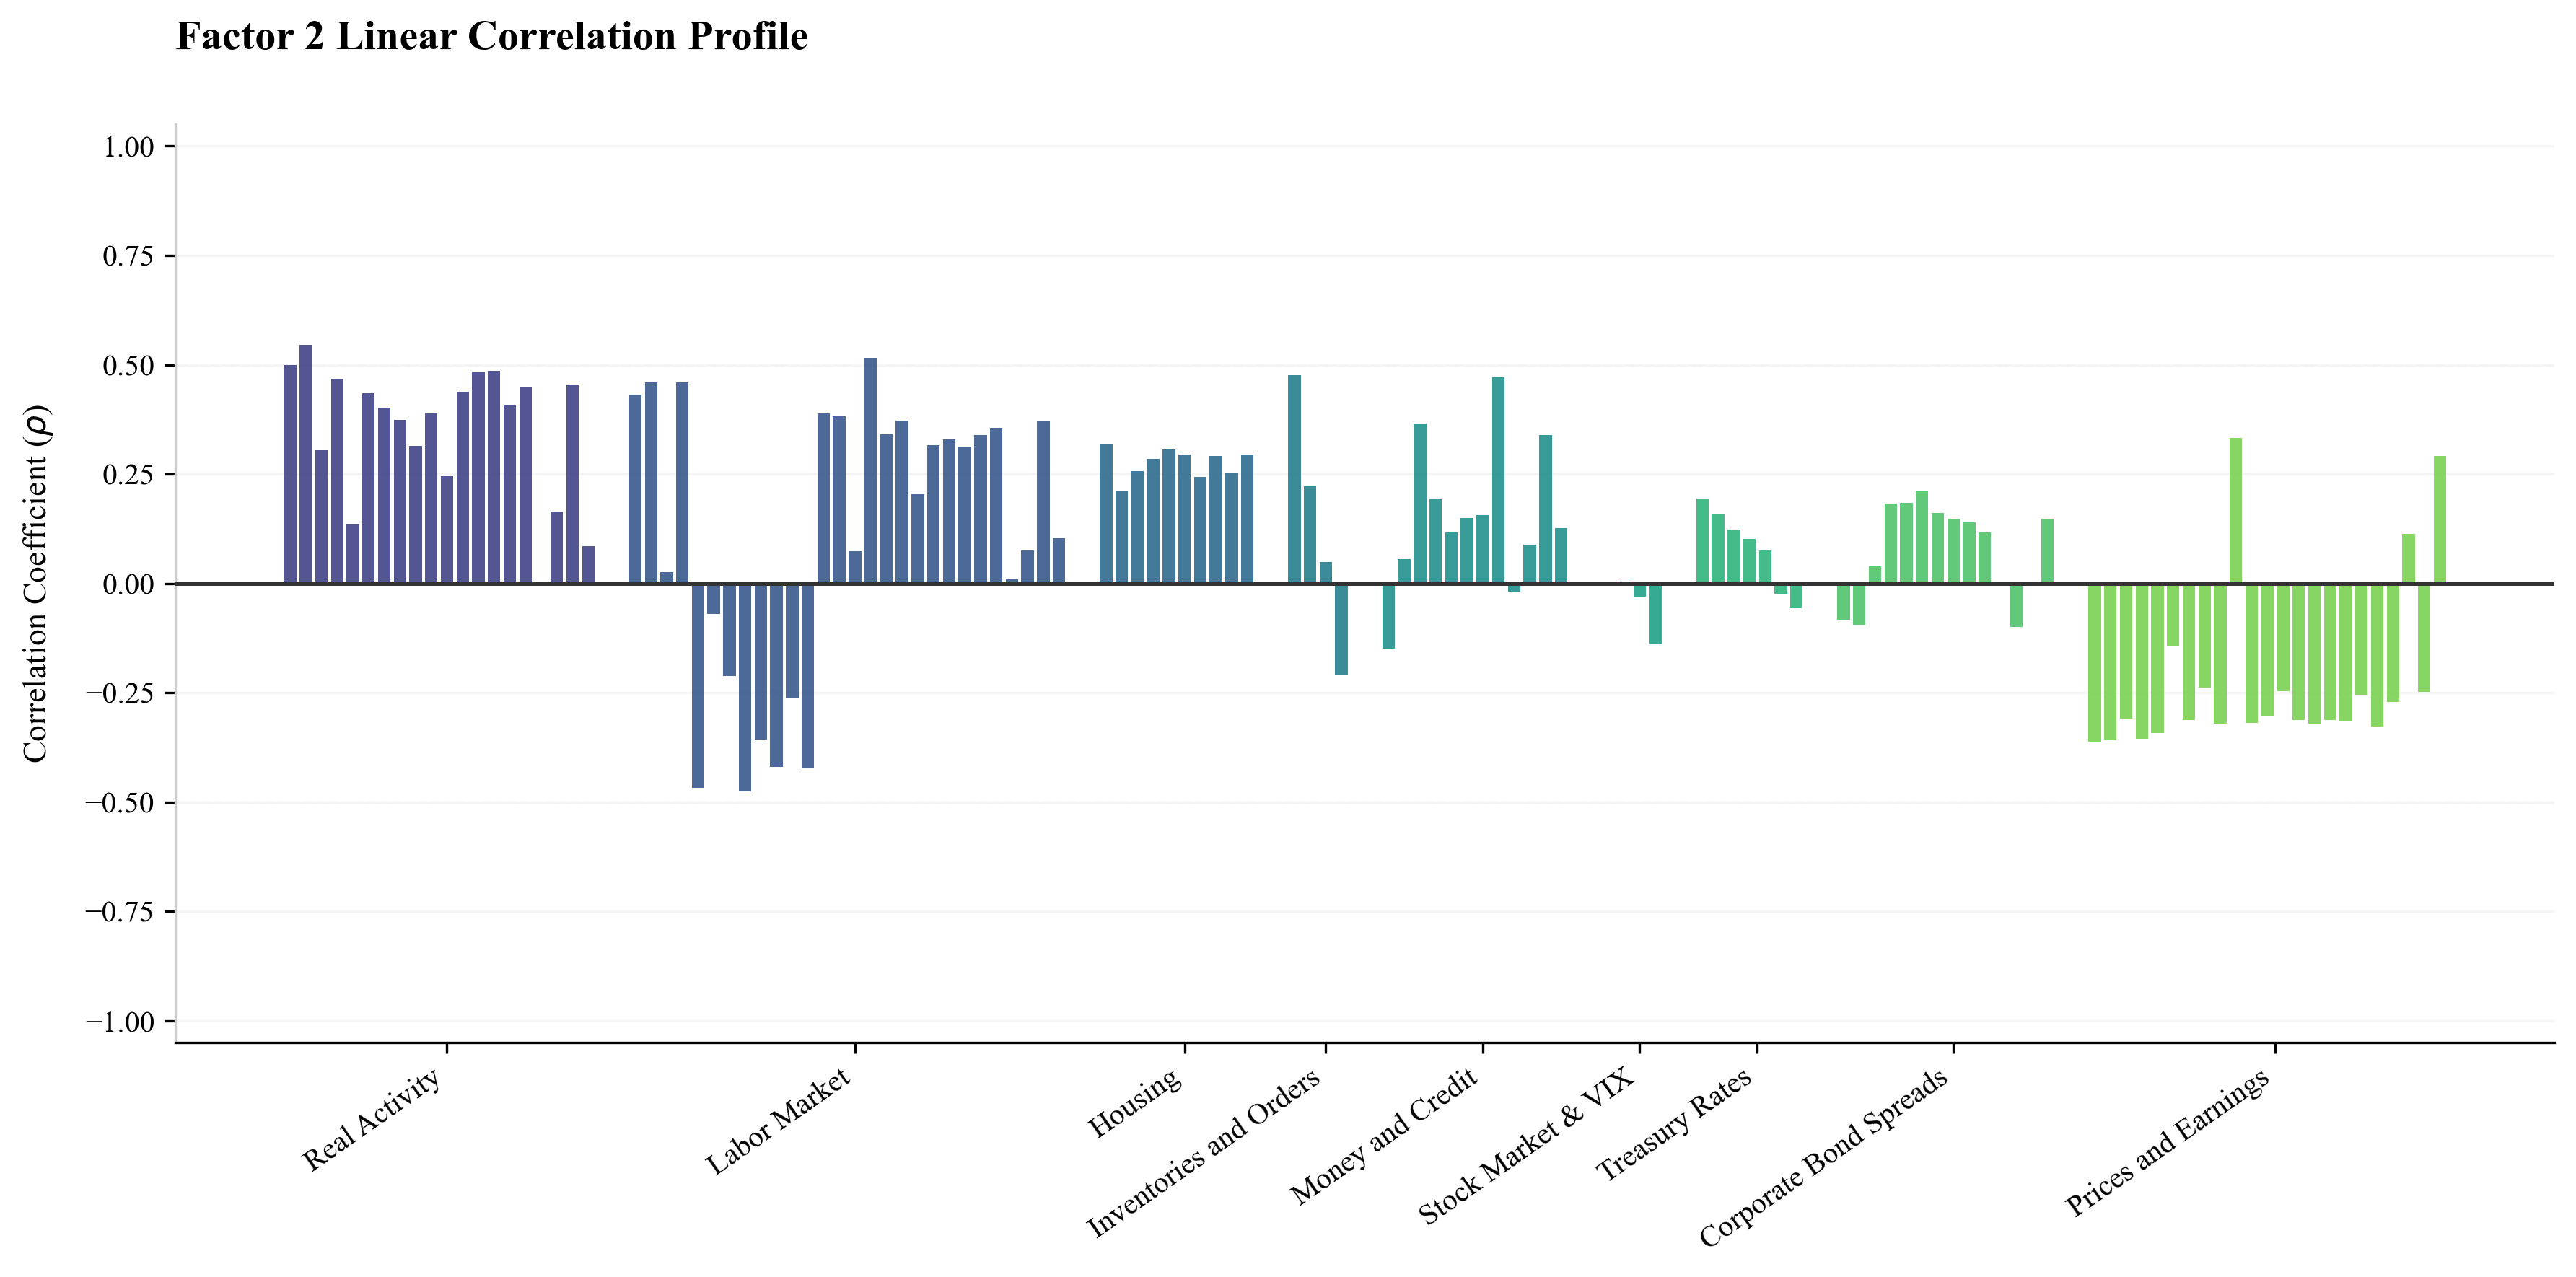

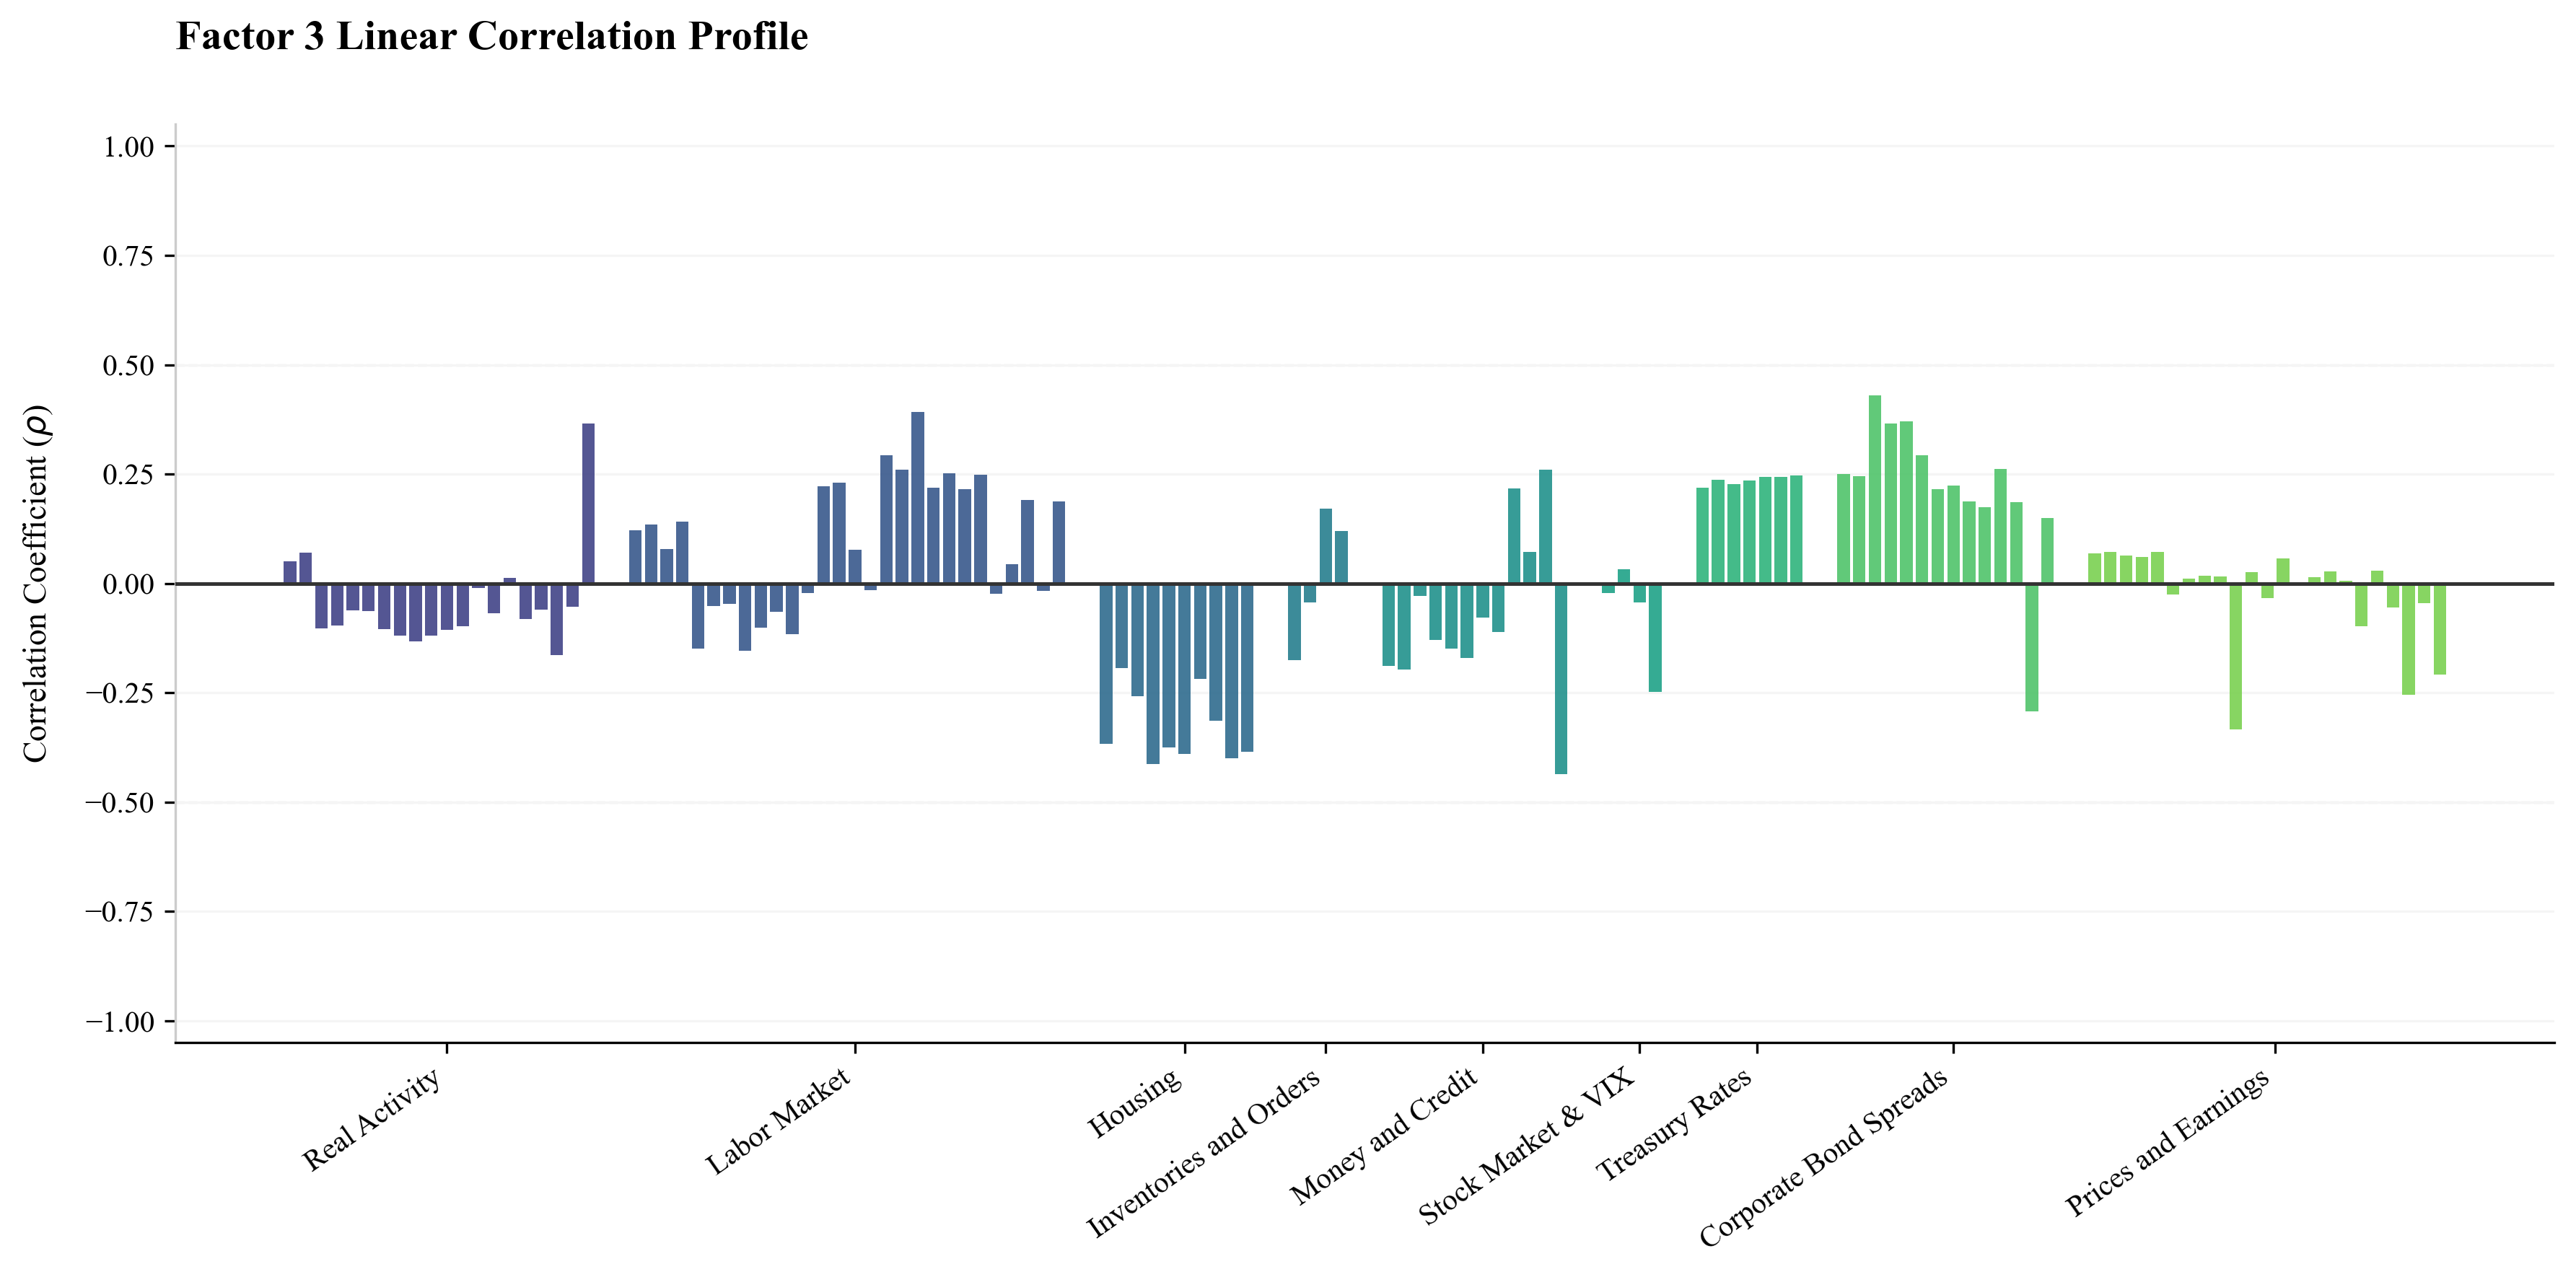

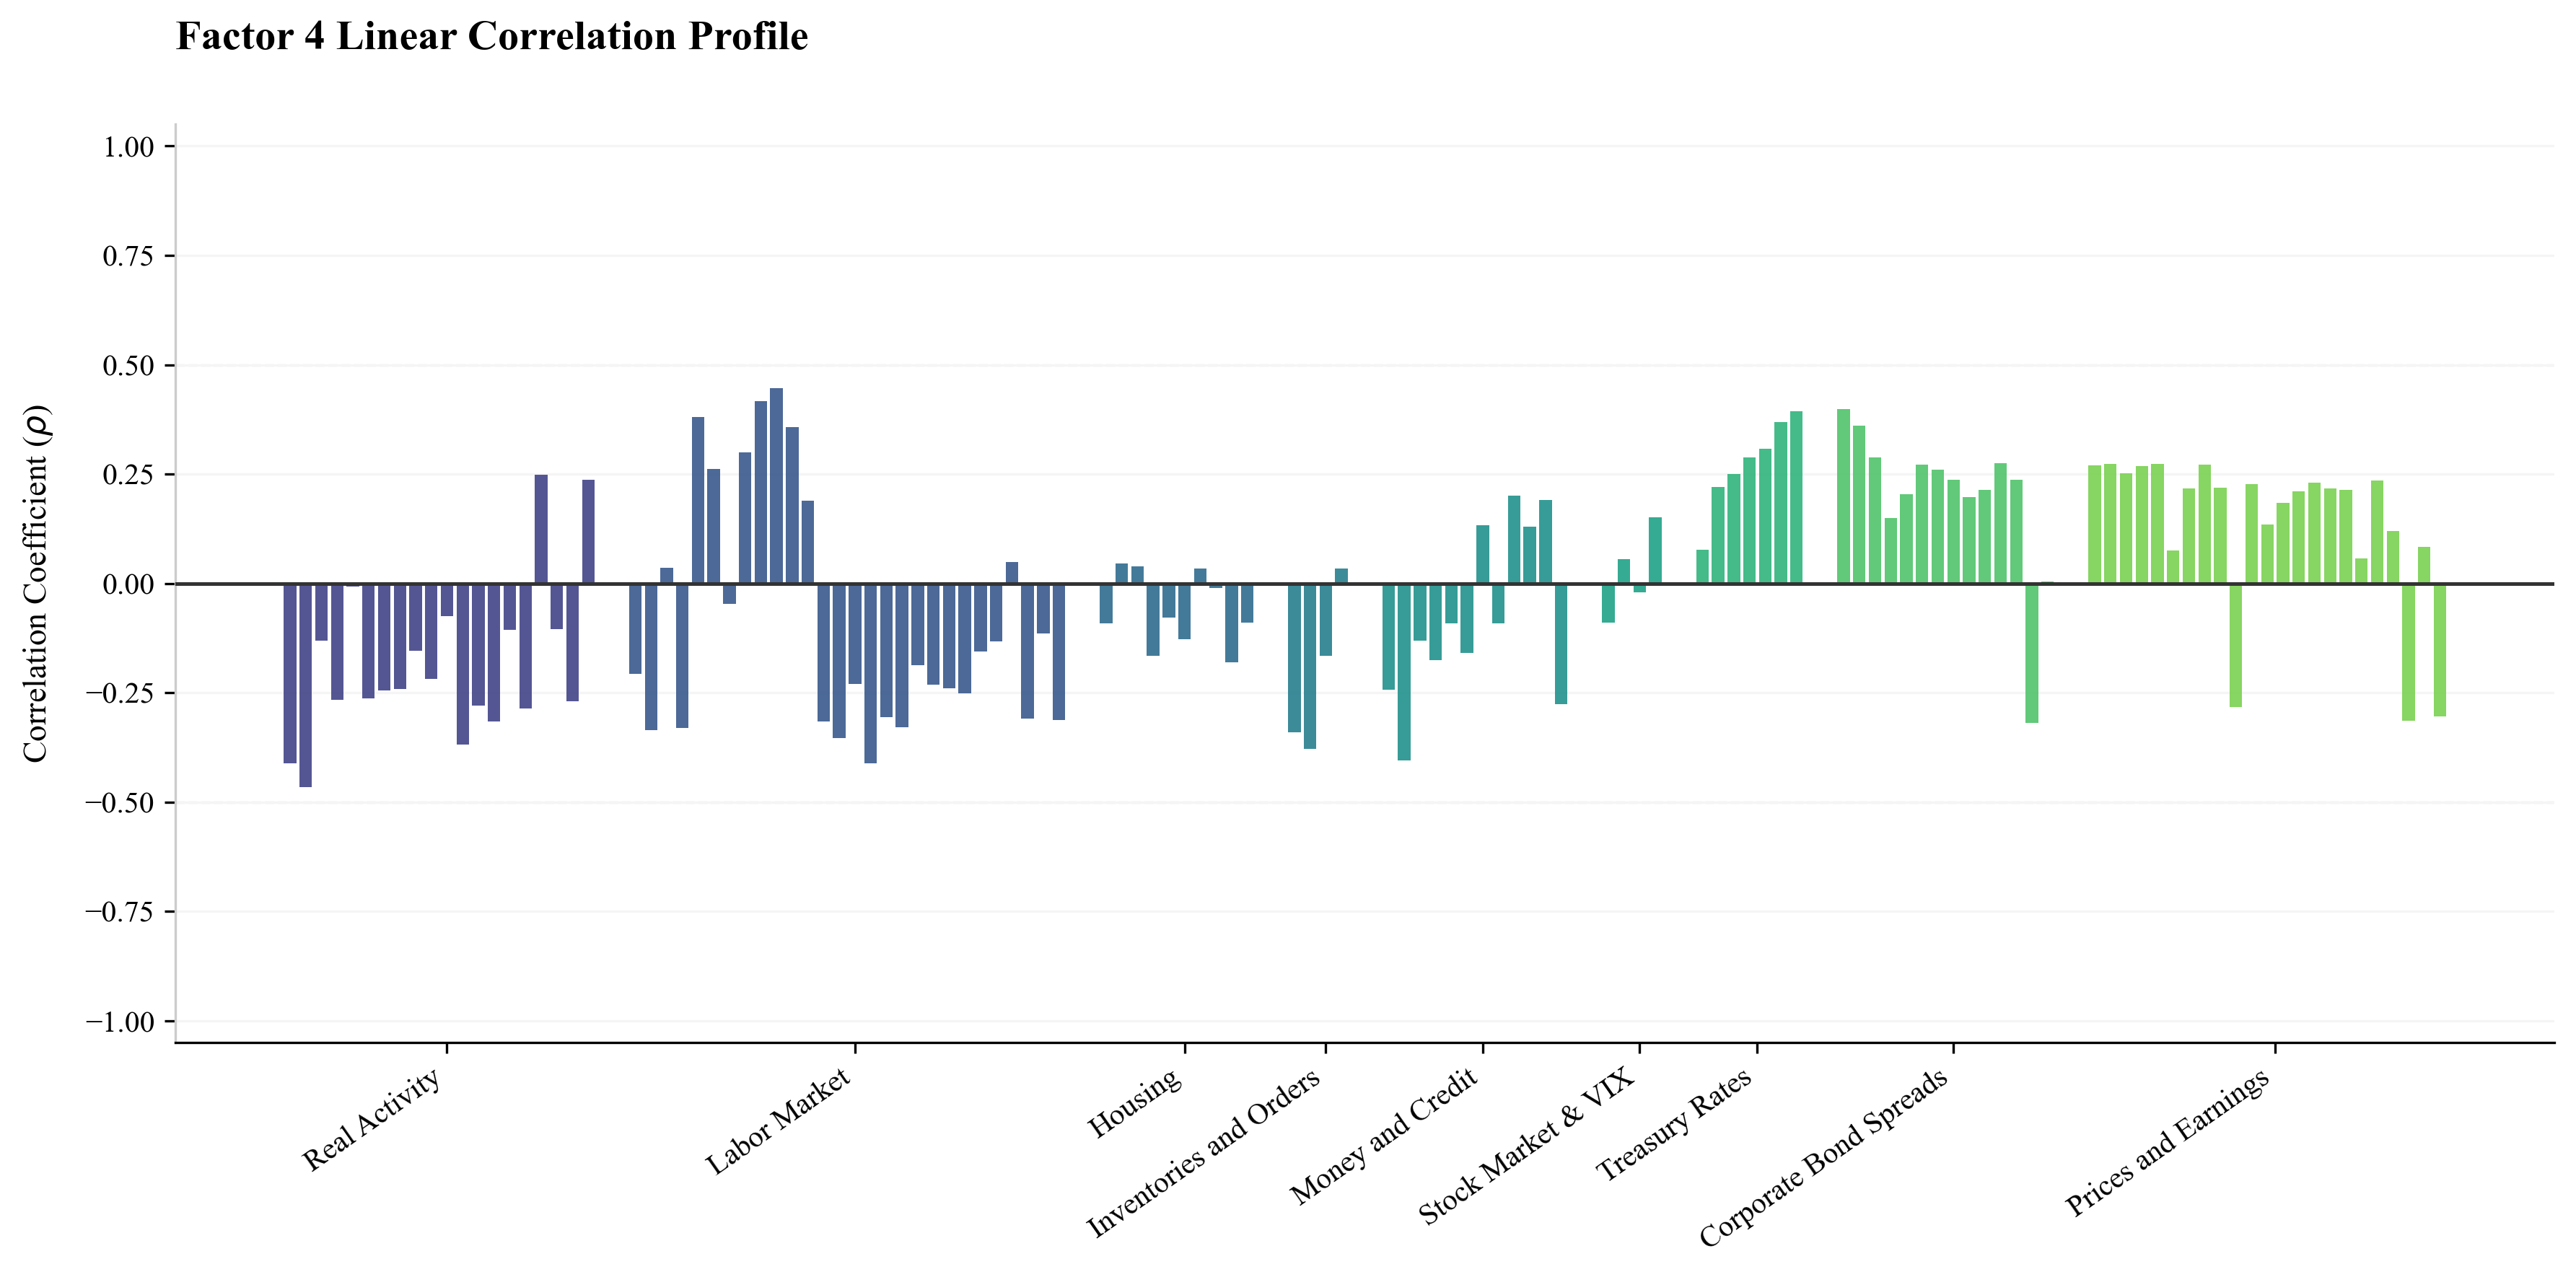

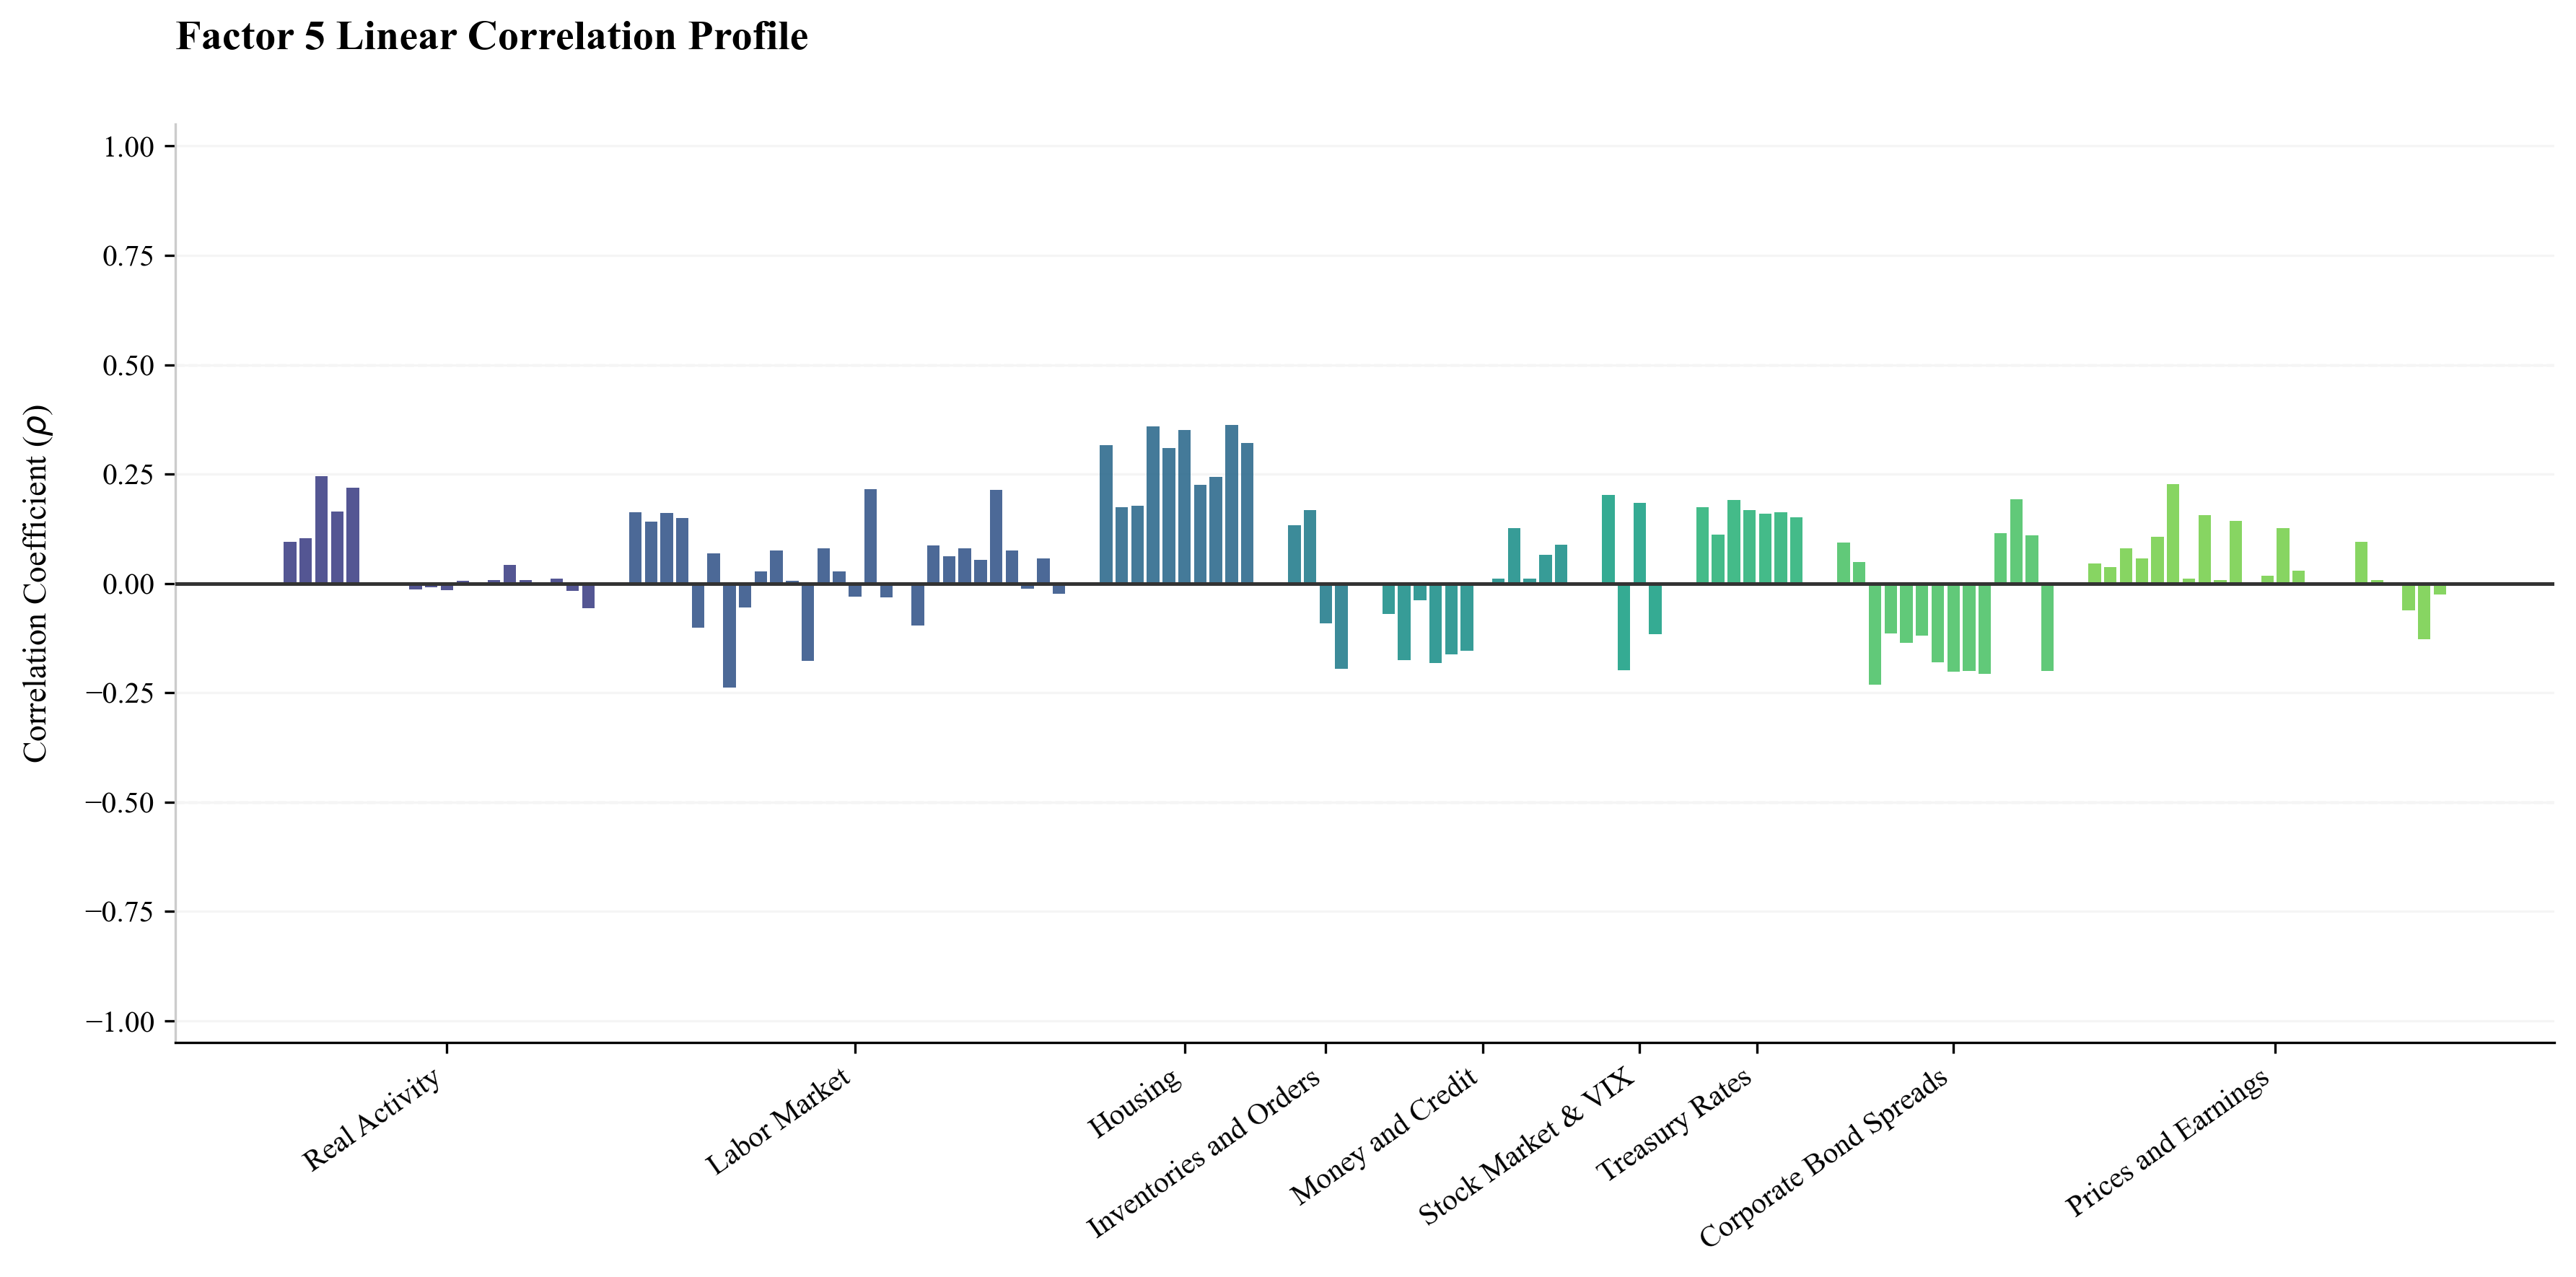

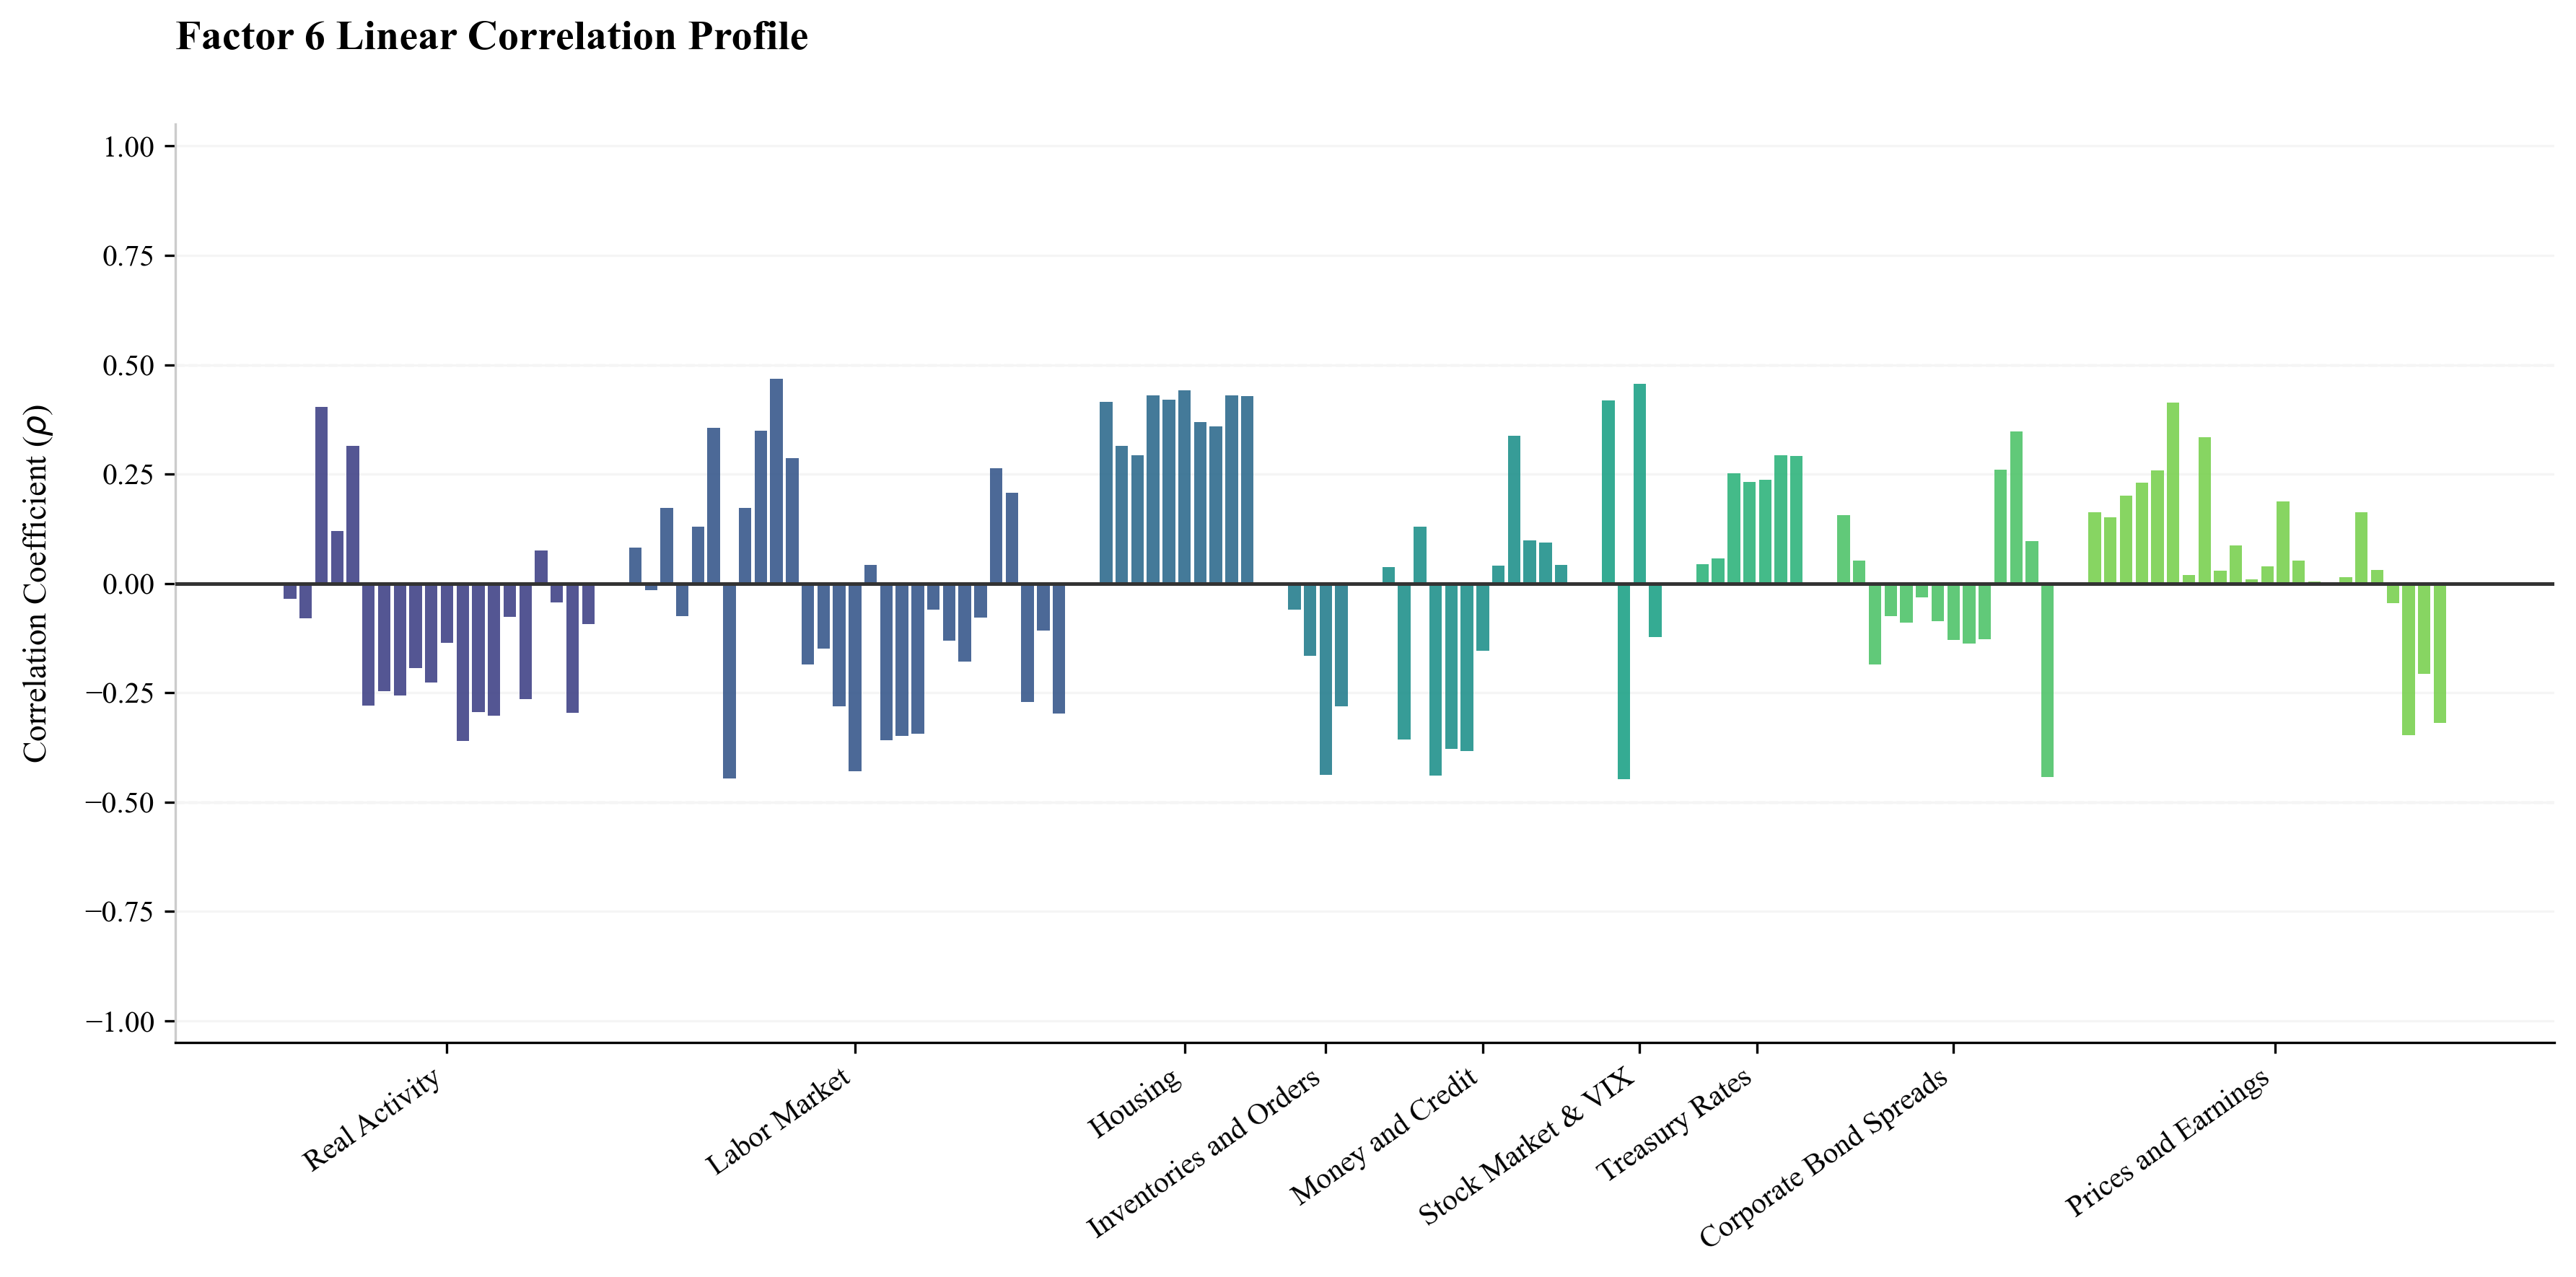

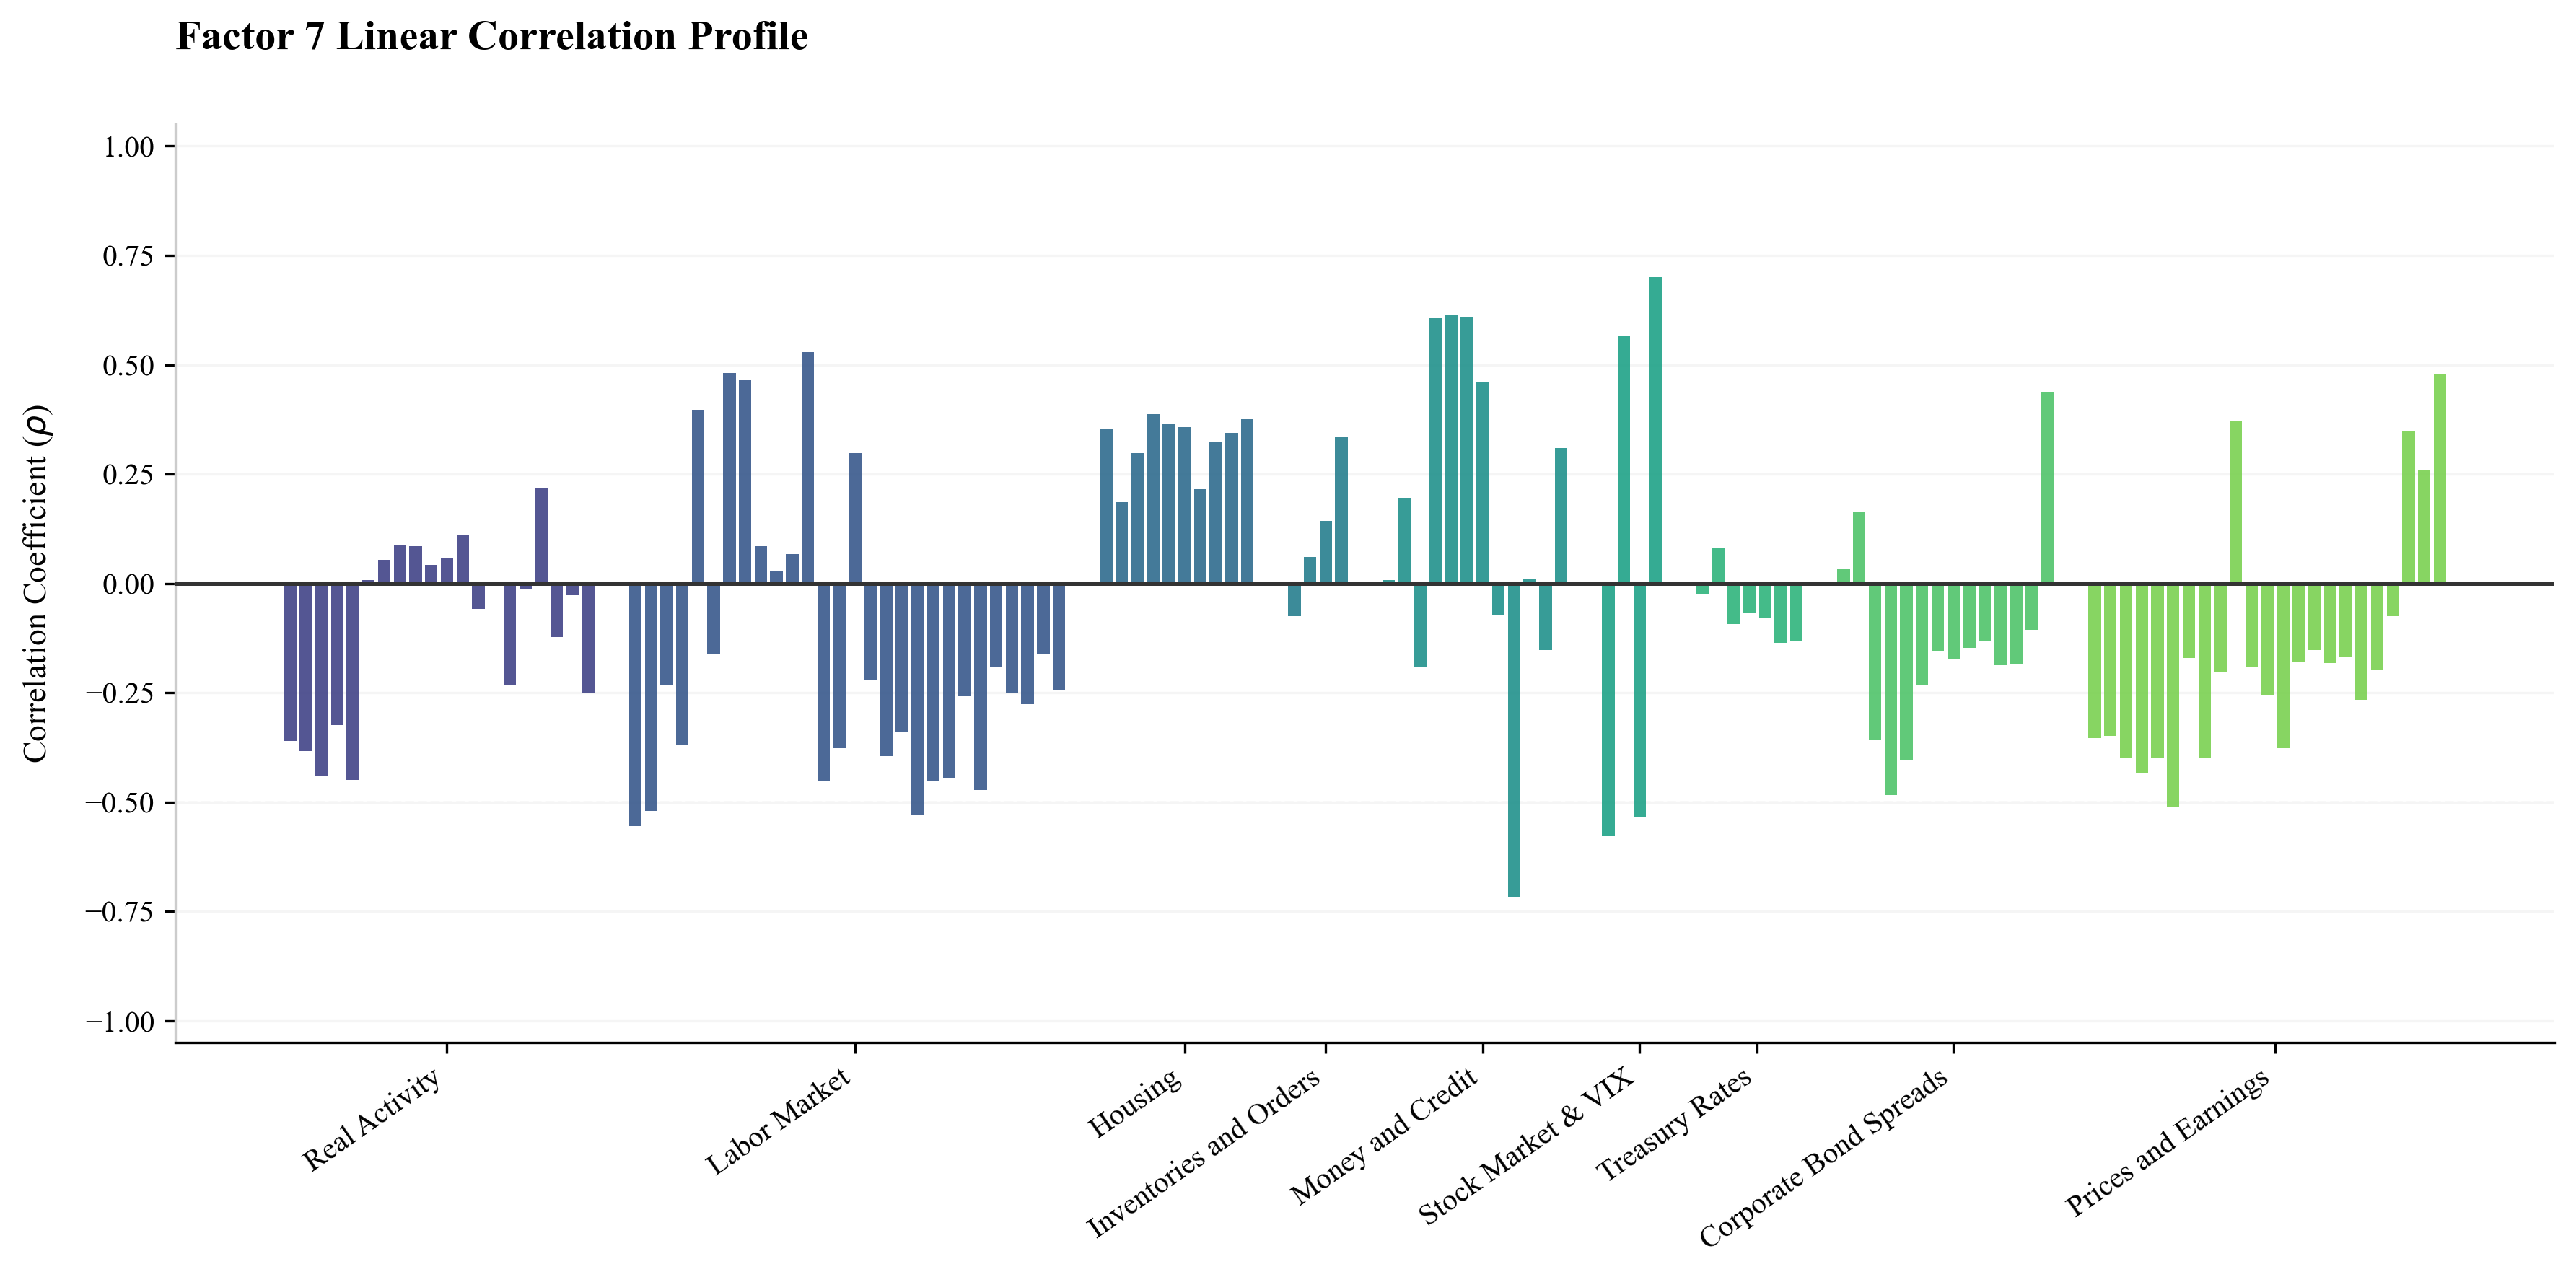

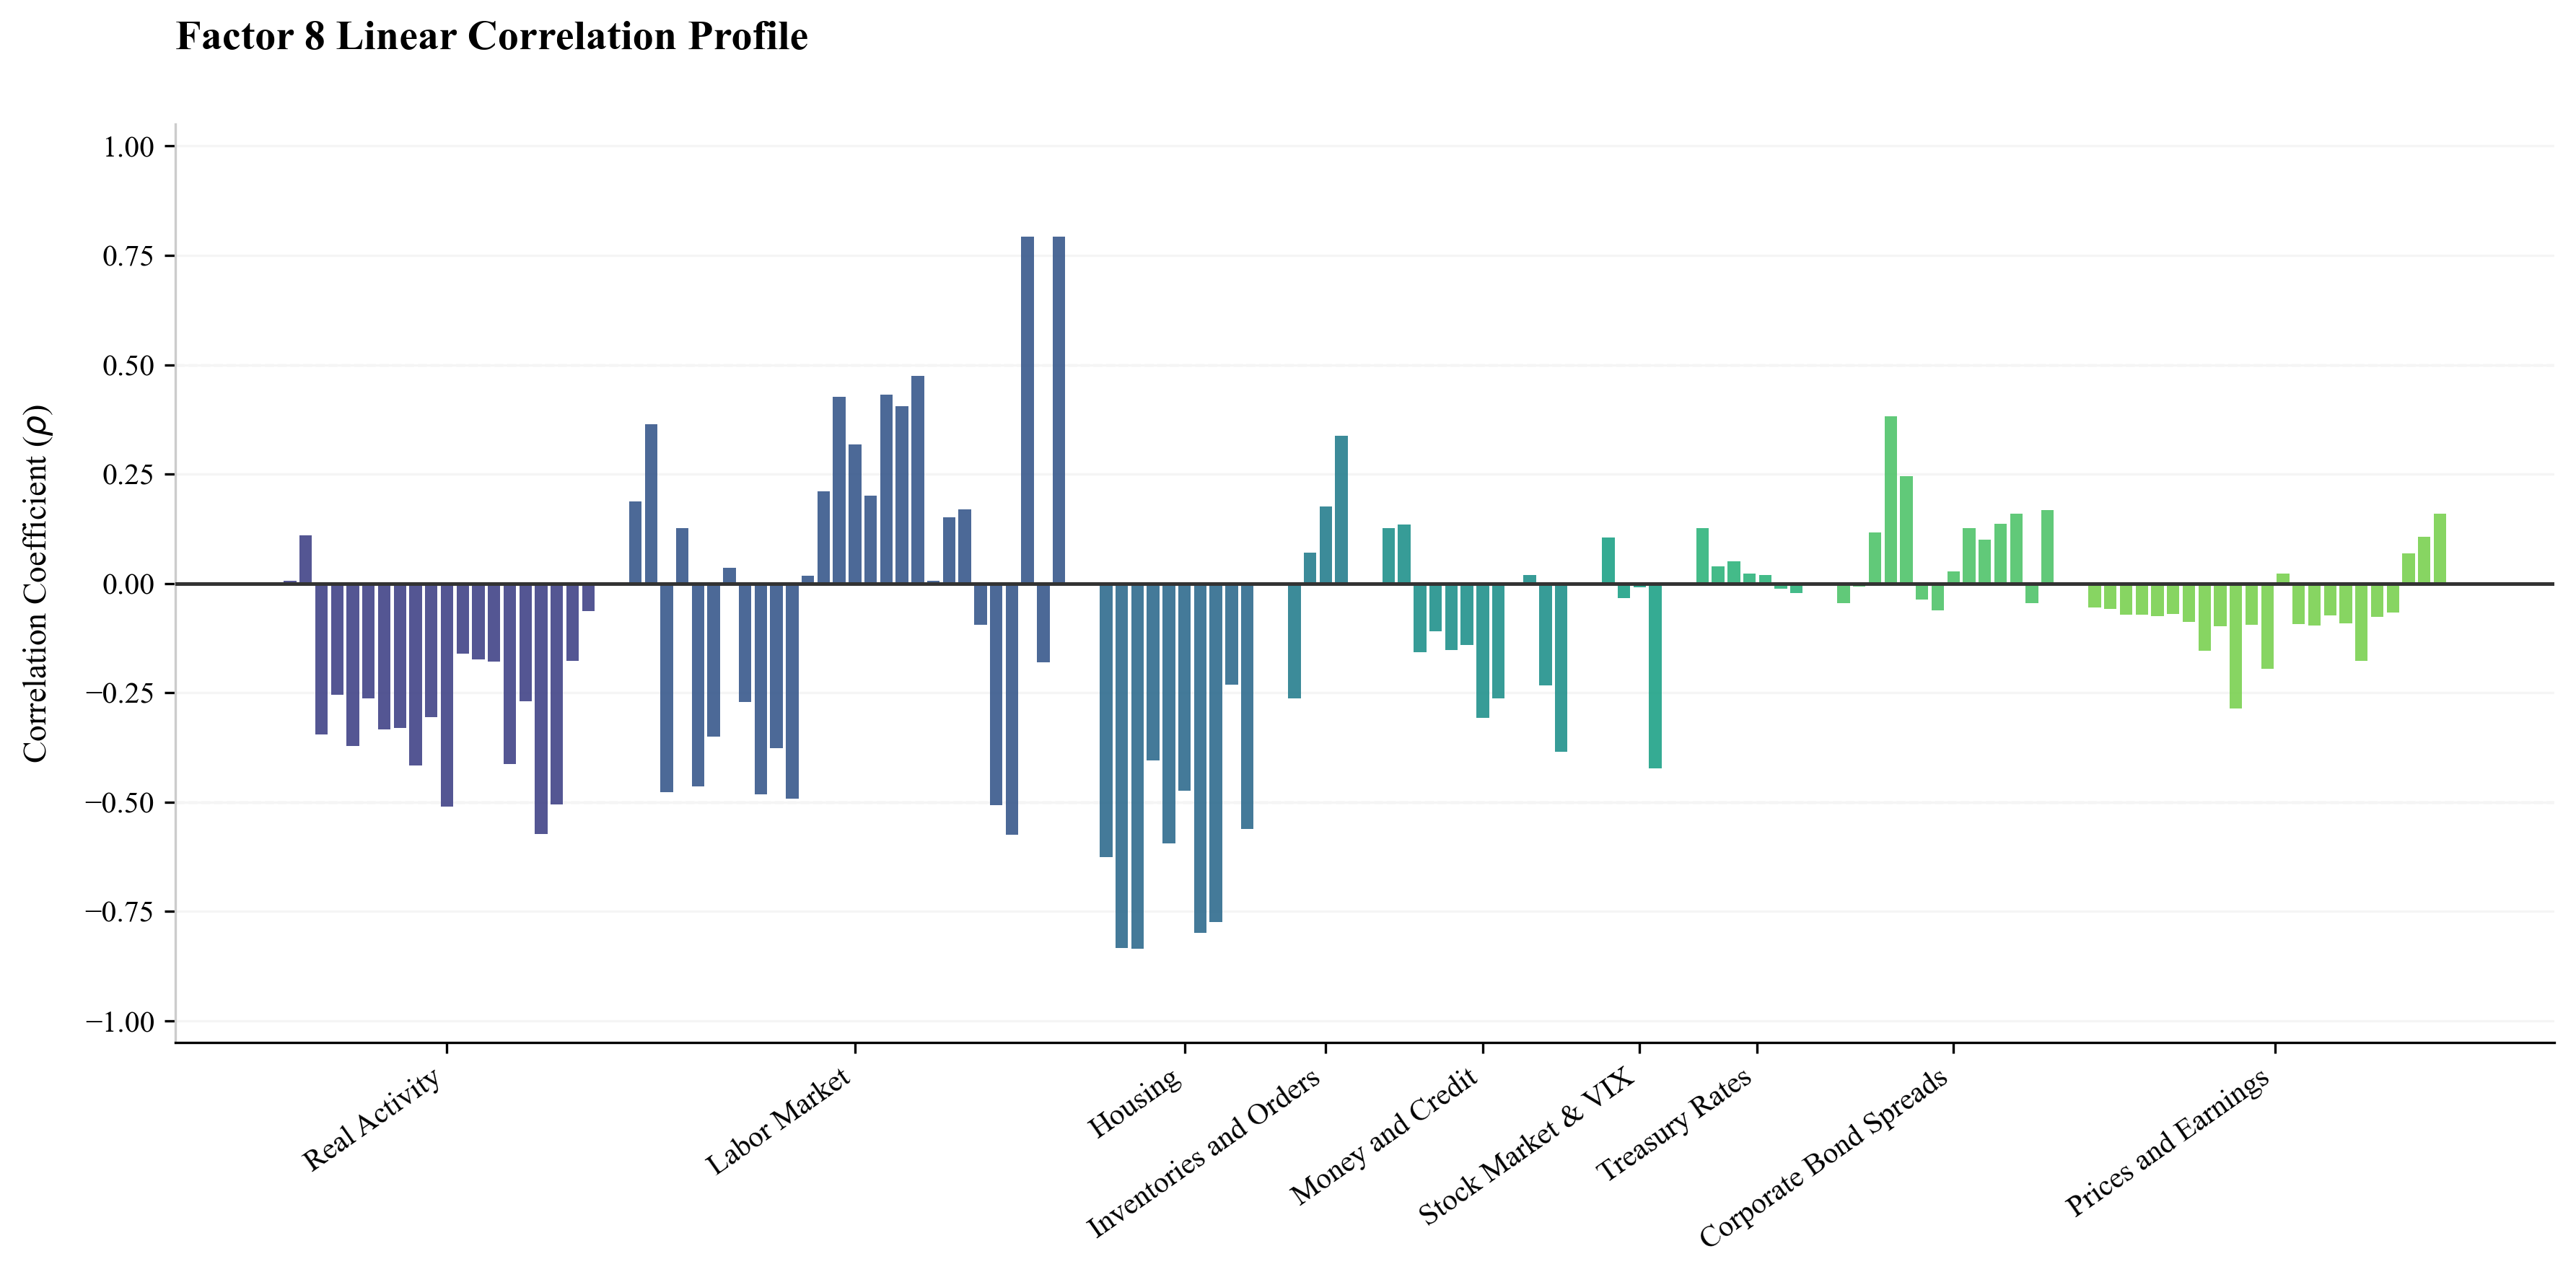

In [11]:
corr_table = pd.DataFrame(index=df_processed.columns, columns=factors.columns)

for f_col in factors.columns:
    corr_table[f_col] = df_processed[window:].corrwith(factors[f_col])

for idx in range(num_factors):
    plot_factor_corr_profile(corr_table, groups, factor_idx=idx)